# Проект. Исследование стартапов

## Введение

Поле для вашего введения: опишите контекст и цели проекта. Чтобы изменить содержимое ячейки, дважды нажмите на неё или нажмите «Ввод».

## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.


### 1.1. Вывод общей информации

Загрузите необходимые для работы библиотеки.

Совет: если вы неоднократно используете какой-либо код, вынесите его в начало проекта в виде функций.

In [1]:
# Импортируем библиотеки
import pandas as pd


In [2]:
# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

Загрузите все данные по проекту.

In [ ]:
investments_df = pd.read_csv("cb_investments.zip", sep=';', low_memory=False)

In [ ]:
returns_df = pd.read_csv("cb_returns.csv")

In [5]:
from matplotlib.ticker import FuncFormatter

Выведите информацию, которая необходима для принятия решений о предобработке.

In [6]:
investments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [7]:
investments_df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
returns_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


In [9]:
returns_df.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


Сделайте вывод о полученных данных: каков их объём, соответствуют ли данные описанию, есть ли пропущенные значения, используются ли верные типы данных. Отметьте другие особенности данных, которые вы обнаружите на этой стадии и на которые стоит обратить внимание при предобработке.

Датафрейм `cb_investments`:
 
- В Датафрейме `cb_investments` всего 54 294 строки и 40 столбцов.  
- В Датафрейме `returns_df` всего 15 строки и 14 столбцов.  

1. **Типы данных**:

- Датафрейм `cb_investments`:

    - 24 столбца имеют тип `float64`.  
    - 16 столбцов имеют тип `object`.

- Датафрейм `returns_df`:

    - Все столбцы числовые.
    - 13 столбцов имеют тип `float64`.
    - 1 столбец имеет тип `float64`

2. **Пропущенные значения**:

- Датафрейм `cb_investments`:

    - Все столбцы имеют пропущенные значения, что требует внимания при предобработке.
   
- Датафрейм `returns_df`:

    - Пропуски отсутствуют.

3. **Особенности данных**:  
   - Столбцы с типом `object` могут содержать строки, которые нужно преобразовать в числовой тип или тип даты. А также проверить на наличие ошибок.  
   - Числовые столбцы с типом `float64` могут быть округлены или преобразованы в `int`, при необходимости.


### 1.2. Предобработка данных

Проверьте названия столбцов в датасетах: все ли они точно отражают содержимое данных и оформлены в удобном для работы стиле. При необходимости приведите их к единому аккуратному стилю.

In [10]:
# Выводим названия столбцов для investments_df
display("Столбцы в investments_df:")
display(investments_df.columns)

# Выводим названия столбцов для returns_df
display("\nСтолбцы в returns_df:")
display(returns_df.columns)
 

'Столбцы в investments_df:'

Index(['name', 'homepage_url', 'category_list', ' market ',
       ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region',
       'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

'\nСтолбцы в returns_df:'

Index(['year', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
       'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding'],
      dtype='object')

In [11]:
# Избавляемся от лишних пробелов в названии столбцов
investments_df.rename(columns={' funding_total_usd ': 'funding_total_usd'}, inplace=True)
investments_df.rename(columns={' market ': 'market'}, inplace=True)

Уберите в столбце `funding_total_usd` выделение разрядов и приведите его к числовому типу.

In [12]:
# Убираем выделение разрядов и преобразуем в числовой тип
investments_df['funding_total_usd'] = investments_df['funding_total_usd'].str.replace(',', '')
investments_df['funding_total_usd'] = pd.to_numeric(investments_df['funding_total_usd'], errors='coerce', downcast='float')

Обработайте типы данных в столбцах, которые хранят значения даты и времени, если это необходимо.

In [13]:
# Преобразуем столбцы в формат datetime
investments_df['founded_at'] = pd.to_datetime(investments_df['founded_at'], errors='coerce')
investments_df['first_funding_at'] = pd.to_datetime(investments_df['first_funding_at'], errors='coerce')
investments_df['mid_funding_at'] = pd.to_datetime(investments_df['mid_funding_at'])
investments_df['last_funding_at'] = pd.to_datetime(investments_df['last_funding_at'], errors='coerce')

investments_df['founded_month'] = pd.to_datetime(investments_df['founded_month'])
# Преобразуем формат даты в YYYY-MM
investments_df['founded_month'] = investments_df['founded_month'].dt.strftime('%Y-%m')

investments_df['founded_quarter'] = pd.to_datetime(investments_df['founded_quarter'], format='%Y-%q', errors='coerce')
# Преобразуем формат даты в YYYY-QN
investments_df['founded_quarter'] = investments_df['founded_quarter'].dt.strftime('%Y-%q')

investments_df['founded_year'] = pd.to_datetime(investments_df['founded_year'], format='%Y', errors='coerce')

В датасете `cb_returns` сделайте столбец `year` индексом всего датасета, если не делали это при загрузке.

In [14]:
# Устанавливаем столбец year как индекс датасета
returns_df = returns_df.set_index('year')

Обработайте текстовые данные, если это необходимо. Пропуски в текстовых столбцах заполните заглушками там, где это понадобится.

In [15]:
# Заполняем пропуски в текстовых столбцах
investments_df['name'] = investments_df['name'].fillna('-')
investments_df['homepage_url'] = investments_df['homepage_url'].fillna('-')
investments_df['category_list'] = investments_df['category_list'].fillna('-')
investments_df['market'] = investments_df['market'].fillna('-')
investments_df['status'] = investments_df['status'].fillna('-')
investments_df['country_code'] = investments_df['country_code'].fillna('-')
investments_df['state_code'] = investments_df['state_code'].fillna('-')
investments_df['region'] = investments_df['region'].fillna('-')
investments_df['city'] = investments_df['city'].fillna('-')

# Удаляем пробелы по краям в значениях
investments_df['market'] = investments_df['market'].str.strip()

Обработайте полные дубликаты в данных и пропуски в `funding_total_usd`. избавьтесь от тех строк, которые не несут какой-либо информации либо не содержат данных о финансировании.

In [16]:
# Удаляем полные дубликаты
investments_df_cleaned = investments_df.drop_duplicates()

# Убираем строки с пропусками в столбце funding_total_usd
investments_df_cleaned = investments_df_cleaned.dropna(subset=['funding_total_usd'])


Заполните пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмите приблизительно середину интервала между этими двумя датами.

Оцените размер оставшихся пропусков в столбце.

In [17]:
# Считаем изначальный размер пропусков в столбце mid_funding_at
na_count = investments_df_cleaned['mid_funding_at'].isna().sum()

# Функция для вычисления середины интервала между датами
def calc_mid_date(row):
    if pd.notna(row['first_funding_at']) and pd.notna(row['last_funding_at']):
        return row['first_funding_at'] + ((row['last_funding_at'] - row['first_funding_at']) / 2)
    return pd.NA

# Применяем функцию к строкам с пропусками в mid_funding_at
investments_df_cleaned['mid_funding_at'] = investments_df_cleaned.apply(calc_mid_date, axis=1)

# Считаем размер оставшихся пропусков в столбце mid_funding_at
na_count_upd = investments_df_cleaned['mid_funding_at'].isna().sum()

display(f"Количество изначальных пропусков в mid_funding_at: {na_count}")
display(f"Количество оставшихся пропусков в mid_funding_at: {na_count_upd}")

'Количество изначальных пропусков в mid_funding_at: 13676'

'Количество оставшихся пропусков в mid_funding_at: 2'

Оцените полноту данных и сделайте предварительный вывод о том, достаточно ли данных для решения задач проекта. Какой процент данных был отброшен?

In [18]:
total_na_count = investments_df_cleaned.isna().sum().sum()
display(f"Общее количество пропусков в данных: {total_na_count}")


'Общее количество пропусков в данных: 80673'

In [19]:
original_rows = len(investments_df)
cleaned_rows = len(investments_df_cleaned)
count_dropped = original_rows - cleaned_rows
share_dropped = (count_dropped / original_rows)

display(f"Процент исключенных данных: {count_dropped} строк")
display(f"Процент исключенных данных: {share_dropped*100:.2f}%")

'Процент исключенных данных: 13387 строк'

'Процент исключенных данных: 24.66%'

В ходе предобработки, из датафрейма cb_investments было удалено 13 387 строк (или 25%), что является существенным кол-вом.
Данные были удалены на основании полноты дублирования строк, а также отсутствия информации об общем объёме привлечённых инвестиций (столбец `funding_total_usd`).

## Шаг 2. Инжиниринг признаков

При выполнении заданий не забывайте интерпретировать полученные результаты и делать промежуточные выводы.

### 2.1. Группы по срокам финансирования

Разделите все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Визуализируйте соотношение этих групп, создав два графика:

* По количеству компаний: Покажите, какой процент от общего числа компаний относится к каждой из трёх групп.
* По объёму инвестиций: Отобразите, какую долю от общего объёма привлечённых средств получила каждая группа.

Совет: Для ясности и согласованности используйте единую цветовую палитру для всех графиков, чтобы каждая категория (например, «Единичное финансирование») всегда отображалась одним цветом.

In [20]:
# Группировка по количеству раундов финансирования
single_funding = investments_df_cleaned[investments_df_cleaned['funding_rounds'] == 1]
multiple_funding = investments_df_cleaned[investments_df_cleaned['funding_rounds'] > 1]

# Разделение на группы по сроку финансирования
less_than_year = multiple_funding[(multiple_funding['last_funding_at'] - multiple_funding['first_funding_at']) <= pd.Timedelta(days=365)]
more_than_year = multiple_funding[(multiple_funding['last_funding_at'] - multiple_funding['first_funding_at']) > pd.Timedelta(days=365)]

# Подсчёт количества компаний в каждой группе
count_single_funding = len(single_funding)
count_than_year_year = len(less_than_year)
count_more_than_year = len(more_than_year)

# Подсчёт общего объёма инвестиций в каждой группе
total_investments_single_funding = single_funding['funding_total_usd'].sum()
total_investments_less_than_year = less_than_year['funding_total_usd'].sum()
total_investments_more_than_year = more_than_year['funding_total_usd'].sum()


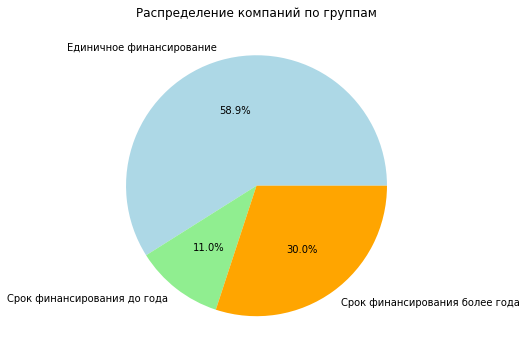

In [21]:
labels = ['Единичное финансирование', 'Срок финансирования до года', 'Срок финансирования более года']
counts = [count_single_funding, count_than_year_year, count_more_than_year]

plt.figure(figsize=(10, 6))
plt.pie(counts, labels=labels, autopct='%1.1f%%', colors=['lightblue', 'lightgreen', 'orange'])
plt.title('Распределение компаний по группам')

plt.show()

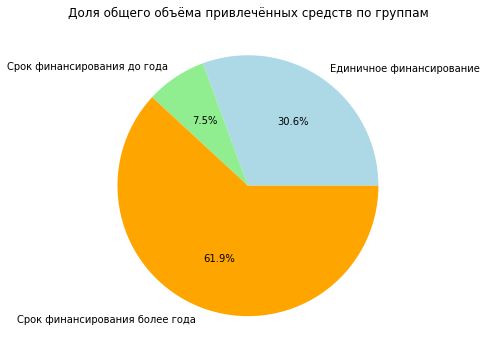

In [22]:
totals = [total_investments_single_funding, total_investments_less_than_year, total_investments_more_than_year]

plt.figure(figsize=(10, 6))
plt.pie(totals, labels=labels, autopct='%1.1f%%', colors=['lightblue', 'lightgreen', 'orange'])
plt.title('Доля общего объёма привлечённых средств по группам')

plt.show()

### 2.2 Выделение средних и нишевых сегментов рынка

Компании указывают свой сегмент рынка в столбце `market`. Рассчитайте, как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесите к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесите к средним, а сегменты до 35 компаний отнесите к нишевым. Рассчитайте, сколько сегментов попадает в каждую из категорий.

Постройте график распределения количества компаний в сегментах и отобразите на нём разделение на нишевые и средние сегменты.

In [23]:
# Подсчитываем количество компаний по каждому сегменту market
segment_counts = investments_df_cleaned['market'].value_counts()

# Определяем категории
massive = segment_counts[segment_counts > 120]
medium = segment_counts[(segment_counts >= 35) & (segment_counts <= 120)]
niche = segment_counts[segment_counts < 35]

# Считаем количество сегментов в каждой категории
num_massive = len(massive)
num_medium = len(medium)
num_niche = len(niche)

# Выводим результат
display(f"Массовые сегменты (>120 компаний): {num_massive}")
display(f"Средние сегменты (35–120 компаний): {num_medium}")
display(f"Нишевые сегменты (<35 компаний): {num_niche}")

'Массовые сегменты (>120 компаний): 49'

'Средние сегменты (35–120 компаний): 57'

'Нишевые сегменты (<35 компаний): 289'

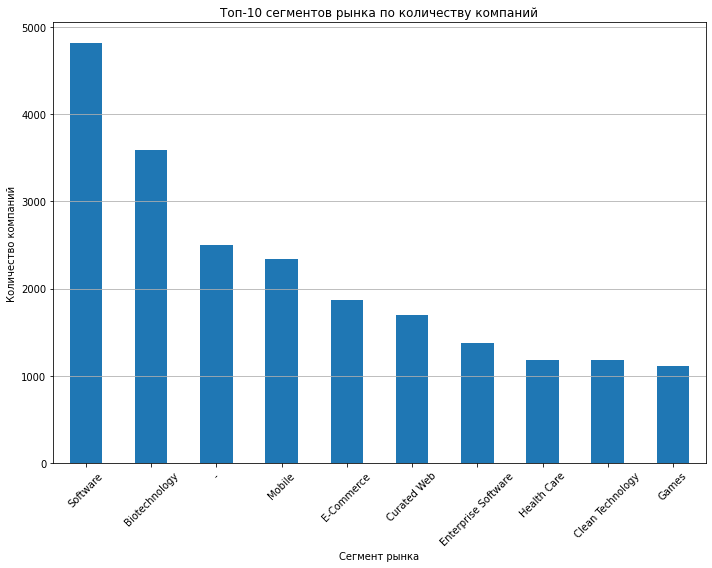

In [24]:
# Берём топ-10 сегментов по количеству компаний
top_10_segments = segment_counts.sort_values(ascending=False).head(10)

# Строим график только для топ-10
plt.figure(figsize=(10, 8))
top_10_segments.plot(kind='bar')
plt.title('Топ-10 сегментов рынка по количеству компаний')
plt.xlabel('Сегмент рынка')
plt.ylabel('Количество компаний')
plt.grid(axis='y')
plt.xticks(rotation=45)  # поворачиваем подписи по оси X для лучшей читаемости
plt.tight_layout()  # улучшает отображение, избегая обрезания подписей
plt.show()

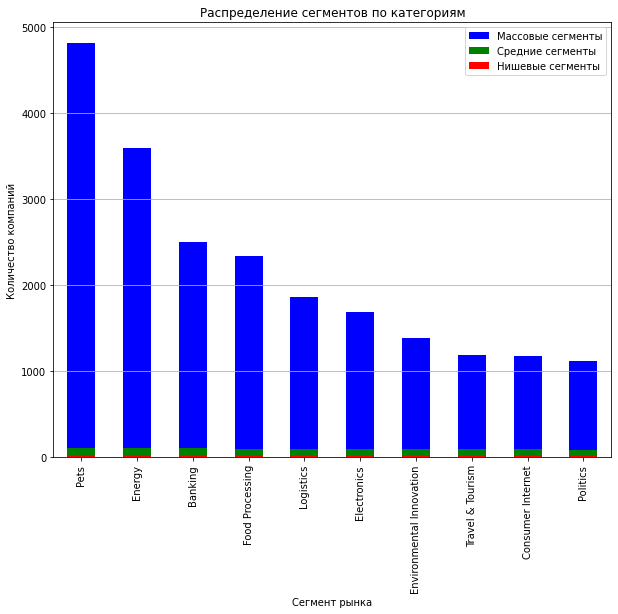

In [25]:
top_10_massive = massive.sort_values(ascending=False).head(10)
top_10_medium = medium.sort_values(ascending=False).head(10)
top_10_niche = niche.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 8))
top_10_massive.plot(kind='bar', color='blue', label='Массовые сегменты')
top_10_medium.plot(kind='bar', color='green', label='Средние сегменты')
top_10_niche.plot(kind='bar', color='red', label='Нишевые сегменты')
plt.title('Распределение сегментов по категориям')
plt.xlabel('Сегмент рынка')
plt.ylabel('Количество компаний')
plt.legend()
plt.grid(axis='y')

plt.show()


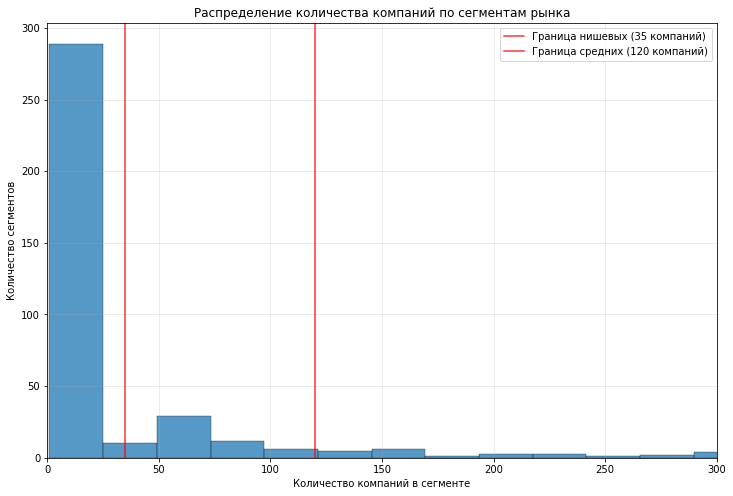

In [26]:
# Строим гистограмму распределения размеров сегментов
plt.figure(figsize=(12, 8))
sns.histplot(segment_counts.values, bins=200)
plt.axvline(35, color='red', linestyle='-', alpha=0.8, label='Граница нишевых (35 компаний)')
plt.axvline(120, color='red', linestyle='-', alpha=0.8, label='Граница средних (120 компаний)')
plt.xlim(0, 300)
plt.title("Распределение количества компаний по сегментам рынка")
plt.xlabel("Количество компаний в сегменте")
plt.ylabel("Количество сегментов")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Оставьте в столбце `market` только массовые сегменты. Для остальных сегментов замените значения на заглушки — `niche` для нишевых и `mid` для средних.

Дальнейшие исследования выполняйте с учётом этой замены. Индивидуальные сегменты внутри средней и нишевой групп рассматривать не нужно — они объединяются в два общих сегмента.


In [27]:
# Создаем копию датасета без заглушек
segment_df = investments_df_cleaned.copy()

In [28]:
# Заменяем значения в столбце 'market'
def classify_market(segment):
    if pd.isna(segment):
        return segment  # оставляем пустоту без изменений
    elif segment in massive:
        return segment
    elif segment in medium:
        return 'mid'
    else:
        return 'niche'

investments_df_cleaned['market'] = investments_df_cleaned['market'].apply(classify_market)

# Проверка результата
display("Уникальные значения в обновлённом столбце 'market':")
display(investments_df_cleaned['market'].unique())

display(f"\nКоличество строк в датасете после преобразования: {len(investments_df_cleaned)}")



"Уникальные значения в обновлённом столбце 'market':"

array(['Education', '-', 'mid', 'Social Media', 'Hardware + Software',
       'Biotechnology', 'Hospitality', 'Enterprise Software',
       'Manufacturing', 'Finance', 'Design', 'niche', 'Nonprofits',
       'Software', 'Curated Web', 'Health Care', 'Health and Wellness',
       'Clean Technology', 'Web Hosting', 'E-Commerce', 'Automotive',
       'Medical', 'Fashion', 'Security', 'Networking', 'Analytics',
       'Semiconductors', 'Public Relations', 'Travel', 'Consulting',
       'Real Estate', 'Technology', 'Music', 'Advertising', 'Games',
       'Mobile', 'Internet', 'Sports', 'Photography', 'News', 'Search',
       'Messaging', 'Video', 'Marketplaces', 'Entertainment', 'SaaS',
       'Cloud Computing', 'Big Data', 'Apps', 'Social Network Media',
       'Startups'], dtype=object)

'\nКоличество строк в датасете после преобразования: 40907'

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

По предобработанному столбцу `funding_total_usd` графическим образом оцените, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. Укажите интервал, в котором лежат типичные значения.

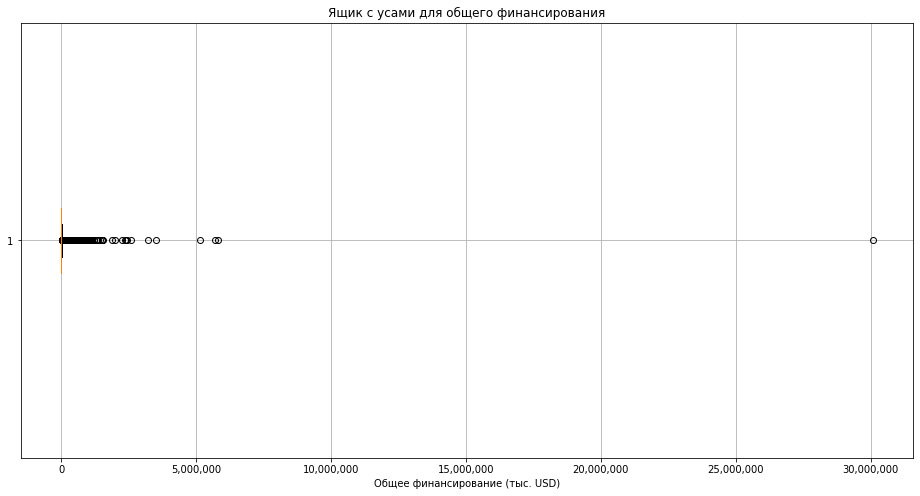

In [29]:
# Создаем график для общего финансирования
plt.figure(figsize=(16, 8))
plt.boxplot(investments_df_cleaned['funding_total_usd'], vert=False, showmeans=False)
plt.title('Ящик с усами для общего финансирования')
plt.xlabel('Общее финансирование (тыс. USD)')
plt.grid()

# Форматируем ось X, чтобы значения отображались в тысячах
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1000:,.0f}'))

plt.show()

In [30]:
# Выведем статистическую информацию
desc = investments_df_cleaned['funding_total_usd'].describe()
display(desc.apply(lambda x: f"{x:,.0f}".replace(',', ' '))) # Исправим формат отображения в привычный вид

count            40 907
mean         15 912 524
std         168 678 784
min                   1
25%             350 000
50%           2 000 000
75%          10 000 000
max      30 079 502 336
Name: funding_total_usd, dtype: object

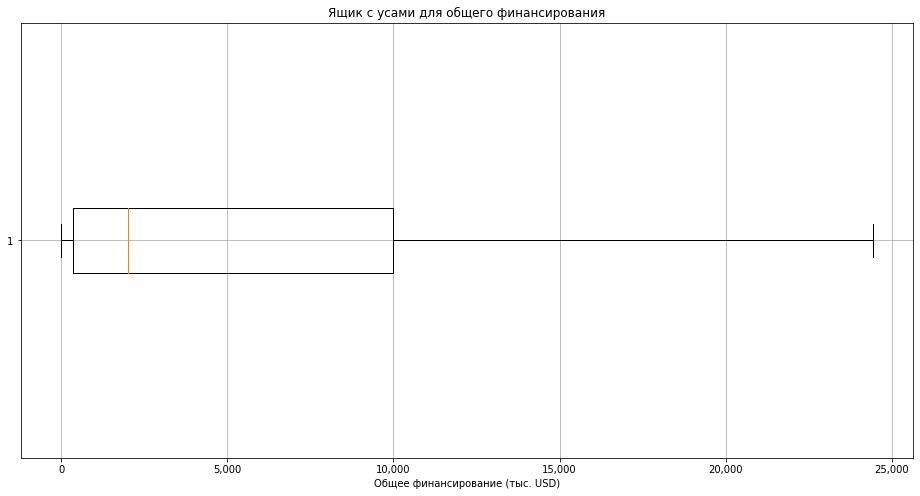

In [31]:
# Создаем график для общего финансирования (без отображения выбросов)
plt.figure(figsize=(16, 8))
plt.boxplot(investments_df_cleaned['funding_total_usd'], vert=False, showmeans=False, showfliers=False)
plt.title('Ящик с усами для общего финансирования')
plt.xlabel('Общее финансирование (тыс. USD)')
plt.grid()

# Форматируем ось X, чтобы значения отображались в тысячах
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1000:,.0f}'))

plt.show()

На основе данных можно сделать вывод, что типичный диапазон размера общего финансирования для одной компании находится в промежутке от 0 до 24 500 тыс. USD

Определите компании с аномальным объёмом общего финансирования — используйте метод IQR отдельно по каждому сегменту. Напомним, что все нишевые сегменты должны быть объединены в одну группу, а средние — в другую.

Определите сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведите топ таких сегментов.

In [32]:
# Функция для определения аномалий по IQR
def find_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (series < lower_bound) | (series > upper_bound)

# Применяем к каждой группе по market
investments_df_cleaned['is_outlier'] = investments_df_cleaned.groupby('market')['funding_total_usd'].transform(find_outliers_iqr)

# Группируем по market и считаем долю аномалий
outlier_stats = []

for group_name, group_df in investments_df_cleaned.groupby('market'):
    total = len(group_df)
    if total == 0:
        continue
    outliers = find_outliers_iqr(group_df['funding_total_usd'])
    n_outliers = outliers.sum()
    outlier_ratio = n_outliers / total
    outlier_stats.append({
        'segment': group_name,
        'total_companies': total,
        'outlier_companies': n_outliers,
        'outlier_ratio': outlier_ratio
    })

# Преобразуем в DataFrame
outlier_df = pd.DataFrame(outlier_stats)

# Сортируем по доле аномалий (по убыванию) и выводим топ
top_outlier_segments = outlier_df.sort_values('outlier_ratio', ascending=False)

# Выводим результат
top_outlier_segments[['segment', 'outlier_ratio', 'total_companies', 'outlier_companies']]

,segment,outlier_ratio,total_companies,outlier_companies
35,Real Estate,0.172043,279,48
15,Entertainment,0.166667,150,25
9,Consulting,0.166189,349,58
37,Search,0.164948,291,48
8,Cloud Computing,0.164474,152,25
36,SaaS,0.161765,272,44
33,Photography,0.161765,204,33
45,Technology,0.159664,238,38
47,Video,0.159574,188,30
50,niche,0.159036,830,132


In [33]:
# 3. Создаём столбец категории
def get_category(market):
    market = market.strip()
    if market in massive:
        return 'massive'
    elif market in medium:
        return 'medium'
    elif market in niche:
        return 'niche'
    else:
        return 'other'  # на всякий случай

# Применяем функцию и создаем новый столбец с категориям
segment_df['category'] = segment_df['market'].apply(get_category)

# Удаляем строки с 'other' или NaN в funding_total_usd
segment_df = segment_df[segment_df['category'].isin(['massive', 'medium', 'niche'])].copy()

# Находим аномалии по категориям
segment_df['is_outlier'] = segment_df.groupby('category')['funding_total_usd'].transform(find_outliers_iqr)

# Собираем статистику по категориям
outlier_stats = []

for category in ['massive', 'medium', 'niche']:
    group_df = segment_df[segment_df['category'] == category]
    total = len(group_df)
    n_outliers = group_df['is_outlier'].sum()
    outlier_ratio = n_outliers / total if total > 0 else 0
    outlier_stats.append({
        'category': category,
        'total_companies': total,
        'outlier_companies': n_outliers,
        'outlier_ratio': outlier_ratio
    })

# Создаём итоговый DataFrame
outlier_summary = pd.DataFrame(outlier_stats)

# Сортируем по доле аномалий
outlier_summary = outlier_summary.sort_values('outlier_ratio', ascending=False)

# Выводим результат
outlier_summary[['category', 'outlier_ratio', 'total_companies', 'outlier_companies']]

,category,outlier_ratio,total_companies,outlier_companies
2,niche,0.159036,830,132
1,medium,0.144754,3841,556
0,massive,0.129153,36236,4680


### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Проверьте по датасету, можно ли считать, что вам предоставили полные данные за 2014 год. Затем исключите из датасета компании, которые вы ранее посчитали получившими аномальное финансирование.

Когда исключите аномальные записи, на основе столбцов `mid_funding_at` и `funding_rounds` оставьте в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

In [34]:
# Проверка полноты данных за 2014 год в investments_df_cleaned
display("Данные investments_df_cleaned за 2014 год:")
display(investments_df_cleaned['founded_year'].value_counts()['2014'])  # Подсчитываем количество компаний, основанных в 2014 году

# Проверка полноты данных за 2014 год в returns_df
display("\nДанные returns_df за 2014 год:")
display(returns_df.loc[2014].shape[0])  # Подсчитываем количество возвратов в 2014 году

'Данные investments_df_cleaned за 2014 год:'

2014-01-01    1015
Name: founded_year, dtype: int64

'\nДанные returns_df за 2014 год:'

13

In [35]:
display(returns_df.loc[2014])

seed                     530.75
venture                 7272.01
equity_crowdfunding        1.15
undisclosed              105.72
convertible_note           7.87
debt_financing          1017.75
angel                    293.98
grant                      0.00
private_equity           384.01
post_ipo_equity          262.70
post_ipo_debt             37.20
secondary_market           1.03
product_crowdfunding       0.72
Name: 2014, dtype: float64

По данным датасета `cb_investments`:
Компаний основано в 2014 году - 1015 компаний. Это значительный объём, что позволяет анализировать тренды основания стартапов, распределение по сегментам, средний размер финансирования и т.д.

По данным датасета `cb_returns`:
Данные за 2014 год присутствуют по всем столбцам (включая grant, который равен 0), что говорит о достаточности данных за интересующий год.

In [36]:
# Исключаем аномальные компании
investments_no_anomalies_df = investments_df_cleaned[investments_df_cleaned['is_outlier'] == False].copy()

display(f"Исходное число записей: {len(investments_df_cleaned)}")
display(f"После удаления выбросов: {len(investments_no_anomalies_df)}")

'Исходное число записей: 40907'

'После удаления выбросов: 35663'

In [37]:
# Группируем по году и считаем количество раундов
yearly_rounds = (investments_no_anomalies_df.assign(year=investments_no_anomalies_df['mid_funding_at']).groupby('year')['funding_rounds'].sum())

# Выбираем годы, где суммарное число раундов ≥ 50
active_years = yearly_rounds[yearly_rounds >= 50].index.tolist()

In [38]:
# Добавляем столбец с годом финансирования
investments_no_anomalies_df['year'] = investments_no_anomalies_df['mid_funding_at']

# Оставляем только строки, где год входит в active_years
active_investments_df = investments_no_anomalies_df[investments_no_anomalies_df['year'].isin(active_years)]


### 3.3. Анализ типов финансирования по объёму и популярности

Постройте график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. Ориентируйтесь на значения в столбцах `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding`.

Также постройте график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

Сравните графики и выделите часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

In [39]:
# Список интересующих столбцов
funding_columns = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
    'convertible_note', 'debt_financing', 'angel', 'grant',
    'private_equity', 'post_ipo_equity', 'post_ipo_debt',
    'secondary_market', 'product_crowdfunding'
]

# Суммируем общий объём по каждому типу
total_amounts = active_investments_df[funding_columns].sum().sort_values(ascending=False)

# Считаем количество не-NaN записей (популярность)
popularity = active_investments_df[funding_columns].astype(bool).sum()

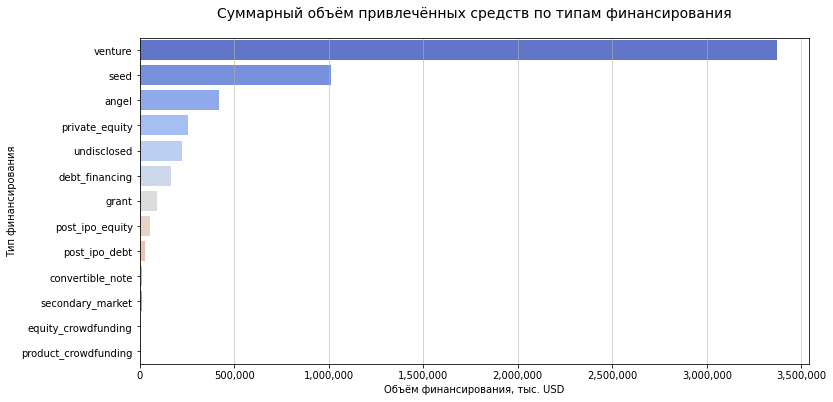

In [40]:
plt.figure(figsize=(12, 6))
sns.barplot(
    x=total_amounts.values,
    y=total_amounts.index,
    palette='coolwarm'
)
plt.title('Суммарный объём привлечённых средств по типам финансирования', fontsize=14, pad=20)
plt.xlabel('Объём финансирования, тыс. USD')
plt.ylabel('Тип финансирования')
plt.grid(axis='x', linestyle='-', alpha=0.7)

# Форматируем ось X, чтобы значения отображались в тысячах
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1000:,.0f}'))

plt.show()


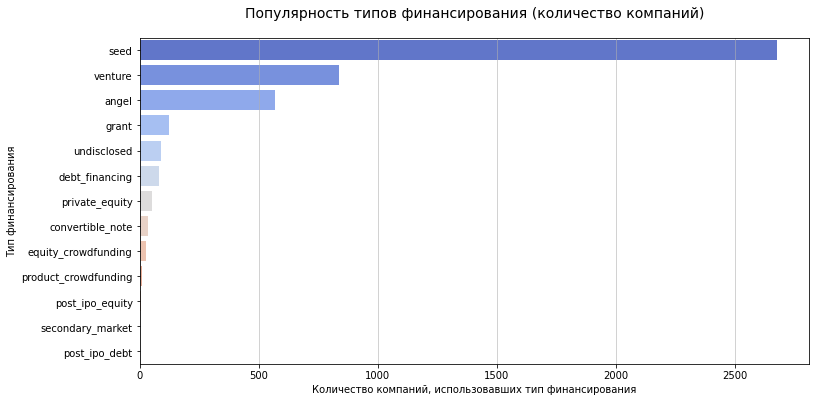

In [41]:
plt.figure(figsize=(12, 6))
sns.barplot(
     x=popularity.sort_values(ascending=False).values,
     y=popularity.sort_values(ascending=False).index,
     palette='coolwarm'
)
plt.title('Популярность типов финансирования (количество компаний)', fontsize=14, pad=20)
plt.xlabel('Количество компаний, использовавших тип финансирования')
plt.ylabel('Тип финансирования')
plt.grid(axis='x', linestyle='-', alpha=0.7)


plt.show()


/tmp/ipykernel_78/2174684322.py:9: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels(total_amounts.index, rotation=45)


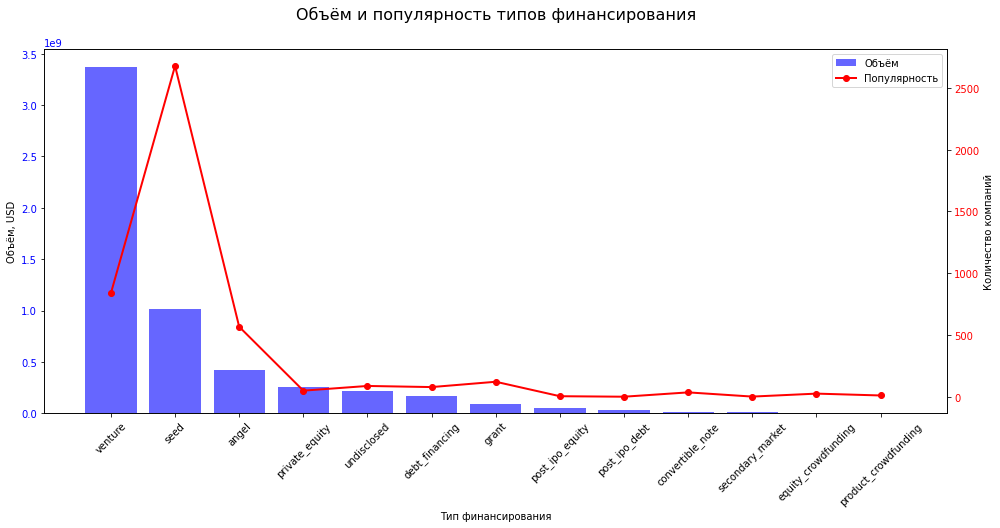

In [42]:
fig, ax1 = plt.subplots(figsize=(14, 7))

# Левая ось — объём (столбцы)
color1 = 'blue'
ax1.set_xlabel('Тип финансирования')
ax1.set_ylabel('Объём, USD')
ax1.bar(total_amounts.index, total_amounts.values, color=color1, alpha=0.6, label='Объём')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticklabels(total_amounts.index, rotation=45)


# Правая ось — популярность (линия)
ax2 = ax1.twinx()
color2 = 'red'
ax2.set_ylabel('Количество компаний')
ax2.plot(total_amounts.index, popularity.loc[total_amounts.index], 
    color=color2, marker='o', linewidth=2, label='Популярность')
ax2.tick_params(axis='y', labelcolor=color2)

# Легенда и заголовок
fig.tight_layout()
plt.title('Объём и популярность типов финансирования', fontsize=16, pad=30)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.show()


In [43]:
comparison = pd.DataFrame({
     'total_amount': total_amounts,
     'count': popularity,
     'avg_per_company': total_amounts / popularity
}).round(2)

comparison.sort_values(['total_amount', 'count'], ascending=False, inplace=True)

display("Сравнение типов финансирования:")
display(comparison.style.format({
    'total_amount': '{:,.0f}',
    'avg_per_company': '{:,.2f}'
}))


'Сравнение типов финансирования:'

,total_amount,count,avg_per_company
venture,"3,373,349,531",839,"4,020,678.82"
seed,"1,011,186,384",2678,"377,590.14"
angel,"419,902,803",567,"740,569.32"
private_equity,"253,132,742",50,"5,062,654.84"
undisclosed,"221,184,298",88,"2,513,457.93"
debt_financing,"165,280,357",79,"2,092,156.42"
grant,"90,605,491",122,"742,667.96"
post_ipo_equity,"55,846,227",5,"11,169,245.40"
post_ipo_debt,"30,000,000",1,"30,000,000.00"
convertible_note,"13,440,421",36,"373,345.03"


На основе графиков и таблицы выделим 4 группы:

**Высокие объёмы + высокая популярность**

- Примеры: `venture`, `seed`.

- Это «ядро» венчурного рынка — много денег и много сделок.

**Высокие объёмы + низкая популярность**

- Примеры: `post_ipo_debt`, `secondary_market`, `post_ipo_equity`.

- Редкие, но крупные сделки (поздние стадии, выходы).

- Высокий средний чек (avg_per_company).

**Низкие объёмы + высокая популярность**

- Примеры: `product_crowdfunding`, `equity_crowdfunding`.

- Много мелких сделок — ранняя стадия, поддержка стартапов.

- Низкий средний чек, но большой охват.

**Низкие объёмы + низкая популярность**

- Примеры: `post_ipo_debt`, `secondary_market`, `post_ipo_equity`.

- Нишевый инструмент; либо недостаточно развит, либо специфичен.

Постройте график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

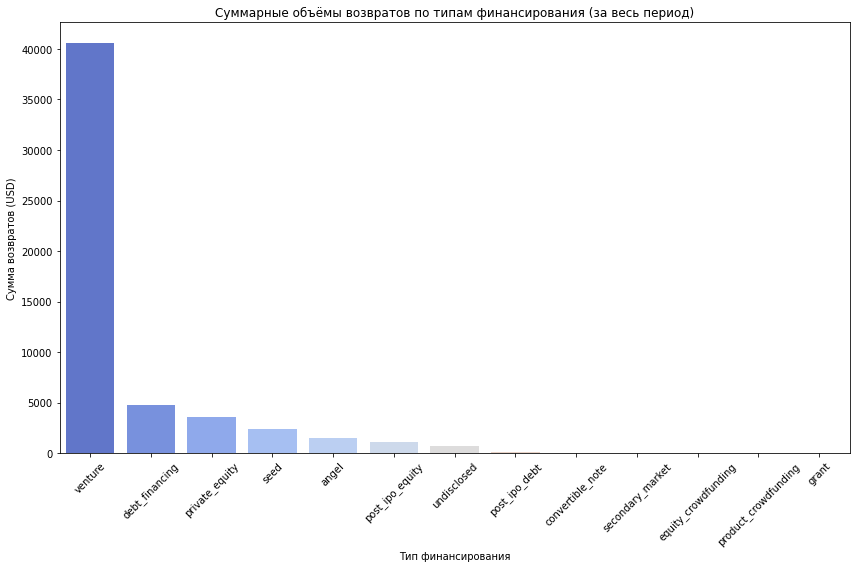

In [44]:
# Суммируем по каждому типу за весь период
total_returns = returns_df[funding_columns].sum()

# Преобразуем в DataFrame для удобства
returns_summary = total_returns.to_frame(name='total_return_usd').reset_index()
returns_summary.columns = ['funding_type', 'total_return_usd']

# Сортируем по убыванию суммы возвратов
returns_summary = returns_summary.sort_values('total_return_usd', ascending=False)

# Построим график
plt.figure(figsize=(12, 8))
sns.barplot(data=returns_summary, x='funding_type', y='total_return_usd', palette='coolwarm')
plt.title('Суммарные объёмы возвратов по типам финансирования (за весь период)')
plt.ylabel('Сумма возвратов (USD)')
plt.xlabel('Тип финансирования')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [45]:
# Выведем таблицу
display(returns_summary)

,funding_type,total_return_usd
1,venture,40578.62
5,debt_financing,4734.85
8,private_equity,3587.33
0,seed,2382.24
6,angel,1509.23
9,post_ipo_equity,1104.96
3,undisclosed,730.88
10,post_ipo_debt,91.03
4,convertible_note,34.79
11,secondary_market,5.20


Согласно полученным данным:

- Лидеры по объёмам возвратов (`venture`, `debt_financing`, `private_equity`). Кроме того, важно отметить существенную разницу между `возратами venture` и `debt_financing`.

- Типы с минимальными возвратами (`grant`, `product_crowdfunding`, `equity_crowdfunding`).

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Используя столбцы `funding_total_usd` и `funding_rounds`, рассчитайте для каждой компании средний объём одного раунда финансирования.

На основе получившейся таблицы постройте графики, отражающие:
* динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;

* динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).

Когда будете строить графики в этом задании и следующих, используйте данные только по тем компаниям, которые остались в датасете после предыдущих фильтраций.

На основе полученных данных ответьте на вопросы:
* В каком году типичный размер средств, собранных в рамках одного раунда, был максимальным?

* Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?

In [46]:
# Оставляем только компании с хотя бы одним раундом
active_investments_df['mid_funding_year'] = active_investments_df['mid_funding_at']
active_investments_df = active_investments_df[active_investments_df['funding_rounds'] > 0]

# Считаем средний размер одного раунда
active_investments_df['avg_round_size'] = active_investments_df['funding_total_usd'] / active_investments_df['funding_rounds']

# Преобразуем в дату, затем извлекаем только год (как целое число)
active_investments_df['mid_funding_year'] = pd.to_datetime(active_investments_df['mid_funding_year']).dt.year

/tmp/ipykernel_78/3128234784.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  active_investments_df['mid_funding_year'] = active_investments_df['mid_funding_at']


In [47]:
# Группируем по году
yearly_stats = active_investments_df.groupby('mid_funding_year').agg(
    total_rounds=('funding_rounds', 'sum'),                     # общее число раундов в год
    median_round_size=('avg_round_size', 'median'),            # типичный (медианный) размер раунда
    mean_round_size=('avg_round_size', 'mean'),                # среднее
    company_count=('avg_round_size', 'count')                  # сколько компаний в этом году
).reset_index()

# Сортируем по году
yearly_stats = yearly_stats.sort_values('mid_funding_year')

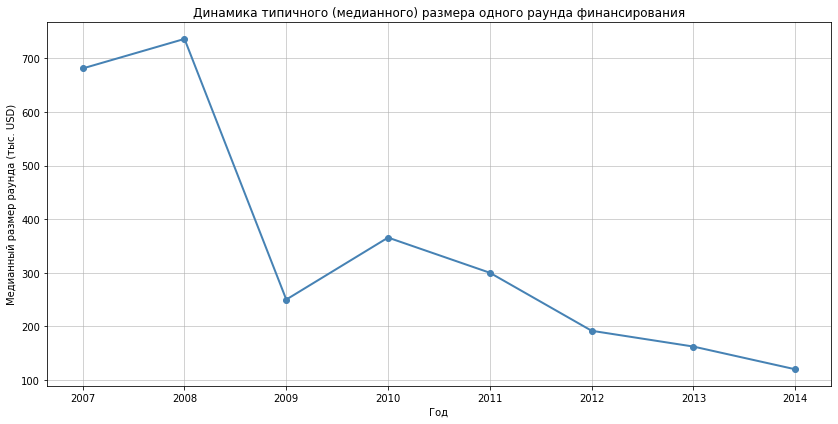

In [48]:
# Строим график Типичный (медианный) размер раунда по годам
plt.figure(figsize=(12, 6))
plt.plot(yearly_stats['mid_funding_year'], yearly_stats['median_round_size'], 
         marker='o', color='steelblue', linewidth=2, markersize=6)
plt.title('Динамика типичного (медианного) размера одного раунда финансирования')
plt.xlabel('Год')
plt.ylabel('Медианный размер раунда (тыс. USD)')
plt.grid(True, linestyle='-', alpha=0.7)
plt.tight_layout()

# Форматируем ось Y, чтобы значения отображались в тысячах
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1000:,.0f}'))

plt.show()

In [49]:
max_median_year = yearly_stats.loc[yearly_stats['median_round_size'].idxmax(), 'mid_funding_year']
max_median_value = yearly_stats['median_round_size'].max()

display(f"Максимальный медианный размер раунда: ${max_median_value:,.0f} в {max_median_year} году")

'Максимальный медианный размер раунда: $736,050 в 2008 году'

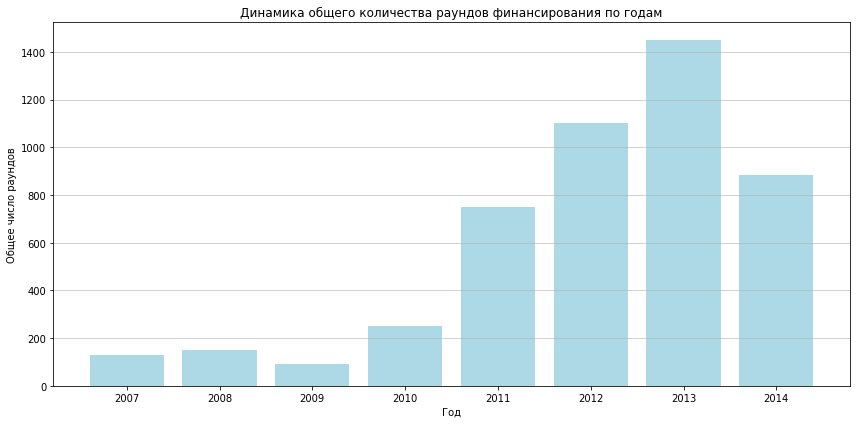

In [50]:
# Строим график Общее количество раундов по годам
plt.figure(figsize=(12, 6))
plt.bar(yearly_stats['mid_funding_year'], yearly_stats['total_rounds'], 
        color='lightblue')
plt.title('Динамика общего количества раундов финансирования по годам')
plt.xlabel('Год')
plt.ylabel('Общее число раундов')
plt.grid(axis='y', linestyle='-', alpha=0.7)
plt.tight_layout()

plt.show()

Как видно на графиках, тенденция в 2014 году по количеству раундов и средств снижалась по сравнению к 2013.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составьте сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. Отберите из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

На графике отразите, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у вас достаточно данных. Рассматривайте только массовые сегменты, а средние и нишевые исключите.

На основе графика сделайте вывод о том, какие сегменты показывают наиболее быстрый и уверенный рост.

In [51]:
# Создаём новый столбец с группировкой
def map_market_to_segment(segment):
    if segment in massive:
        return segment
    elif segment in medium:
        return 'Middle'
    else:
        return 'Niche'

active_investments_df['market_segment'] = active_investments_df['market'].apply(map_market_to_segment)

In [52]:
# Группируем: сумма funding_total_usd по году и сегменту
summary = active_investments_df.groupby(['mid_funding_year', 'market_segment'])['funding_total_usd'].sum().reset_index()

# Создаём сводную таблицу
pivot = summary.pivot(index='mid_funding_year', columns='market_segment', values='funding_total_usd').fillna(0)

# Сортируем по годам
pivot = pivot.sort_index()

# Выводим таблицу
display(pivot)

market_segment,-,Advertising,Analytics,Apps,Automotive,Big Data,Biotechnology,Clean Technology,Cloud Computing,Consulting,...,Semiconductors,Social Media,Social Network Media,Software,Sports,Startups,Technology,Travel,Video,Web Hosting
mid_funding_year,,,,,,,,,,,,,,,,,,,,,
2007,350000.0,14000000.0,28108000.0,0.0,0.0,0.0,277000.0,65000000.0,0.0,5000000.0,...,1448700.0,5575850.0,1631700.0,35608964.0,0.0,0.0,46500000.0,1250000.0,0.0,0.0
2008,2050000.0,35466000.0,0.0,0.0,350000.0,150000.0,33530000.0,42350000.0,0.0,0.0,...,0.0,7904139.0,0.0,16081308.0,0.0,0.0,0.0,4239731.0,3325000.0,1472100.0
2009,100000.0,13402292.0,0.0,0.0,0.0,0.0,12000000.0,15000000.0,0.0,0.0,...,0.0,1350000.0,2970428.0,16812748.0,0.0,0.0,0.0,95000.0,1150000.0,100000.0
2010,10159317.0,35353824.0,2897780.0,3020000.0,4502251.0,0.0,13500000.0,62506500.0,0.0,770000.0,...,0.0,7641994.0,620000.0,48609728.0,7000000.0,30000.0,0.0,489238.0,3495000.0,358416.0
2011,17921752.0,20214488.0,6325292.0,650000.0,16830714.0,9520000.0,90873496.0,67802464.0,4370000.0,256000.0,...,4702194.0,32181368.0,8001936.0,134968944.0,6861000.0,425000.0,130000.0,11867835.0,5207198.0,7541851.0
2012,63064016.0,26644628.0,23864832.0,3833500.0,278082.0,300000.0,72801584.0,33498920.0,4311039.0,4814725.0,...,57632212.0,13906775.0,1181749.0,121762688.0,4019390.0,4018779.0,5968000.0,32894704.0,1395000.0,12997729.0
2013,72093736.0,21177228.0,10331845.0,4019775.0,420897.0,8056112.0,135504208.0,19978548.0,2110743.0,1536375.0,...,6294788.0,18783810.0,542567.0,110816248.0,2779233.0,3474806.0,2261842.0,19984808.0,1298973.0,211389.0
2014,52963652.0,24780924.0,1294656.0,7325390.0,358000.0,370000.0,64882752.0,1560000.0,23865000.0,2450348.0,...,8165642.0,6676782.0,1204066.0,50022676.0,7372710.0,5495000.0,15039501.0,3592604.0,16756504.0,26840460.0


In [53]:
# Проверяем наличие в 2013 и 2014
if 2013 in pivot.index and 2014 in pivot.index:
    # Условие: финансирование в 2014 > 2013 И в 2013 было > 0
    stonks = pivot.columns[
        (pivot.loc[2014] > pivot.loc[2013]) & 
        (pivot.loc[2013] > 0)
    ]
    stonks = list(stonks)
else:
    stonks = []
    display("Нет данных за 2013 или 2014 год!")

display(f"Найдено сегментов с ростом в 2014: {len(stonks)}")
display("Сегменты с ростом в 2014 по сравнению с 2013:")
display(stonks)

'Найдено сегментов с ростом в 2014: 20'

'Сегменты с ростом в 2014 по сравнению с 2013:'

['Advertising',
 'Apps',
 'Cloud Computing',
 'Consulting',
 'E-Commerce',
 'Finance',
 'Hospitality',
 'Internet',
 'Manufacturing',
 'News',
 'Real Estate',
 'SaaS',
 'Security',
 'Semiconductors',
 'Social Network Media',
 'Sports',
 'Startups',
 'Technology',
 'Video',
 'Web Hosting']

In [54]:
massive_grew_2014 = [segment for segment in stonks if segment in massive]

display(f"Из них массовых и выросших в 2014: {len(massive_grew_2014)}")
display("Сегменты:", massive_grew_2014)

# Создаем копию датасета (для датасета только с массовыми сегментами)
massive_df = active_investments_df[active_investments_df['market'].isin(massive_grew_2014)].copy()

'Из них массовых и выросших в 2014: 20'

'Сегменты:'

['Advertising',
 'Apps',
 'Cloud Computing',
 'Consulting',
 'E-Commerce',
 'Finance',
 'Hospitality',
 'Internet',
 'Manufacturing',
 'News',
 'Real Estate',
 'SaaS',
 'Security',
 'Semiconductors',
 'Social Network Media',
 'Sports',
 'Startups',
 'Technology',
 'Video',
 'Web Hosting']

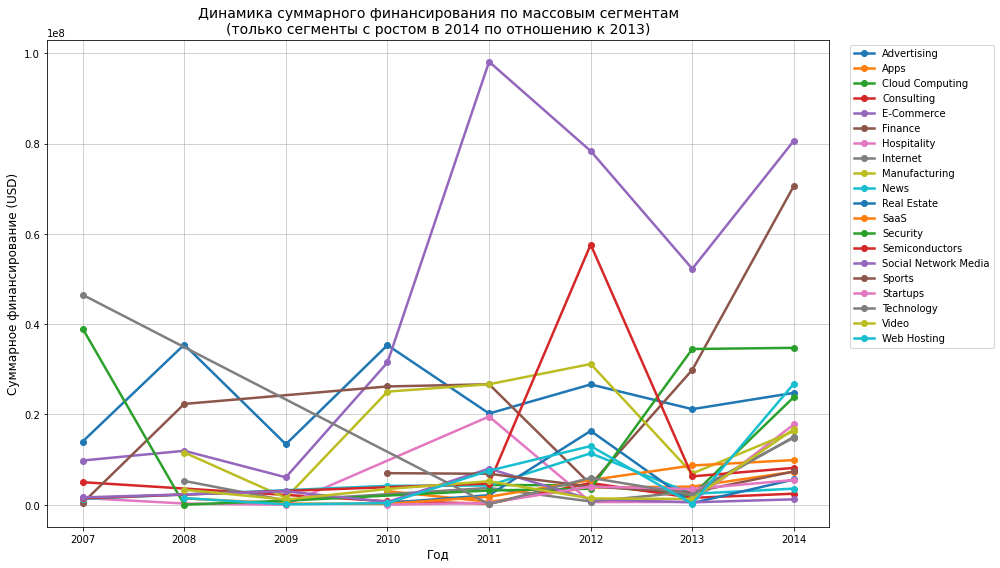

In [55]:
# Свод по году и сегменту на основе df_massive_grew
summary_plot = massive_df.groupby(['market', 'mid_funding_year'])['funding_total_usd'].sum().reset_index()
pivot_plot = summary_plot.pivot(index='mid_funding_year', columns='market', values='funding_total_usd').fillna(0)
pivot_plot = pivot_plot.sort_index()

# График
plt.figure(figsize=(14, 8))
colors = sns.color_palette("tab10", len(massive_grew_2014))

for i, seg in enumerate(massive_grew_2014):
    series = pivot_plot[seg]
    # Рисуем только точки, где сумма > 0 (чтобы не тянуть линию через нули)
    non_zero = series[series > 0]
    if len(non_zero) > 1:
        plt.plot(non_zero.index, non_zero.values, 
                    marker='o', linewidth=2.5, label=seg, color=colors[i])

plt.title('Динамика суммарного финансирования по массовым сегментам\n(только сегменты с ростом в 2014 по отношению к 2013)', fontsize=14)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Суммарное финансирование (USD)', fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.grid(True, linestyle='-', alpha=0.7)
plt.tight_layout()

plt.show()

In [56]:
display(pivot_plot)

market,Advertising,Apps,Cloud Computing,Consulting,E-Commerce,Finance,Hospitality,Internet,Manufacturing,News,Real Estate,SaaS,Security,Semiconductors,Social Network Media,Sports,Startups,Technology,Video,Web Hosting
mid_funding_year,,,,,,,,,,,,,,,,,,,,
2007,14000000.0,0.0,0.0,5000000.0,9800000.0,400000.0,1500000.0,0.0,0.0,1300000.0,0.0,0.0,39020000.0,1448700.0,1631700.0,0.0,0.0,46500000.0,0.0,0.0
2008,35466000.0,0.0,0.0,0.0,11954675.0,22331652.0,275000.0,5276754.0,11573905.0,0.0,0.0,1416828.0,25000.0,0.0,0.0,0.0,0.0,0.0,3325000.0,1472100.0
2009,13402292.0,0.0,0.0,0.0,6080000.0,0.0,25000.0,960273.0,1515454.0,0.0,0.0,273055.0,900000.0,0.0,2970428.0,0.0,0.0,0.0,1150000.0,100000.0
2010,35353824.0,3020000.0,0.0,770000.0,31508726.0,26202648.0,0.0,0.0,25056516.0,4194000.0,415000.0,200000.0,0.0,0.0,620000.0,7000000.0,30000.0,0.0,3495000.0,358416.0
2011,20214488.0,650000.0,4370000.0,256000.0,98111960.0,26686340.0,19541092.0,3725500.0,26692972.0,4260000.0,2122890.0,1780000.0,3164411.0,4702194.0,8001936.0,6861000.0,425000.0,130000.0,5207198.0,7541851.0
2012,26644628.0,3833500.0,4311039.0,4814725.0,78339552.0,4498407.0,599040.0,719066.0,31171540.0,11401104.0,16359284.0,5466686.0,3556920.0,57632212.0,1181749.0,4019390.0,4018779.0,5968000.0,1395000.0,12997729.0
2013,21177228.0,4019775.0,2110743.0,1536375.0,52261460.0,29877176.0,625199.0,2908755.0,6926331.0,2425000.0,384682.0,8697068.0,34497504.0,6294788.0,542567.0,2779233.0,3474806.0,2261842.0,1298973.0,211389.0
2014,24780924.0,7325390.0,23865000.0,2450348.0,80635320.0,70633616.0,17799464.0,14873190.0,16295491.0,3580000.0,5606087.0,9899633.0,34750000.0,8165642.0,1204066.0,7372710.0,5495000.0,15039501.0,16756504.0,26840460.0


**Наиболее быстрый рост** (по темпу):
- **Web Hosting** (+12 600%)  
- **Hospitality** (+2 747%)  
- **Video** (+1 190%)  
- **Cloud Computing** (+1 030%)

Но это **рост с очень низкого уровня** - высокая волатильность, не обязательно устойчивый тренд.

**Наиболее уверенный рост** (высокий темп + высокий уровень):
- **Finance**:  
     - Уровень в 2013: **~30 млн USD**  
     - Рост: **+136%** → +40 млн USD  
     - Абсолютный объём в 2014: **70.6 млн USD** (2-е место после E-Commerce)

- **E-Commerce**:  
     - Уровень в 2013: **52 млн USD**  
     - Рост: **+54%**  
     - Абсолютный объём в 2014: **80.6 млн USD** (лидер)

- **Cloud Computing**:  
     - Уровень в 2013: **2.1 млн USD** → небольшой,  
     - Но рост **+1 030%** → 23.8 млн USD в 2014,  
     - Это **структурный тренд** (облачные технологии набирают обороты в 2013–2014).

**Итоговый вывод:**

- **Наиболее быстрый рост** демонстрируют нишевые сегменты с низкой базой — **Web Hosting**, **Hospitality**, **Video**. Однако их динамика может быть **нестабильной** из-за малого числа компаний.  
 
- **Наиболее уверенный и значимый рост** показывают **Finance** и **E-Commerce** — сегменты с **высокой базой** и **устойчивым двузначным ростом**. Это отражает **макротренды**:  
    - рост финтех-стартапов,  
    - экспансию онлайн-торговли.  

- **Cloud Computing** — сегмент с **наиболее перспективной траекторией**: низкая база в 2013, но взрывной рост в 2014, что предвещает дальнейшее доминирование в последующие годы.

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Ваша цель — для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, нужно заменить на пропуски.

Совет: когда будете делить сумму возвращённых средств на суммарный объём привлечённого финансирования по конкретному году, добавьте к знаменателю небольшое число, например `1e-60`. Это поможет избежать деления на ноль.

In [57]:
funding_pivot = active_investments_df.pivot_table(values=['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 
            'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity',
            'post_ipo_debt', 'secondary_market', 'product_crowdfunding'],
    index='mid_funding_year',
    aggfunc='sum'
)

returns_ratios = returns_df / (funding_pivot + 1e-60)

display(returns_ratios)

,angel,convertible_note,debt_financing,equity_crowdfunding,grant,post_ipo_debt,post_ipo_equity,private_equity,product_crowdfunding,secondary_market,seed,undisclosed,venture
2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2007,0.000005,3.220000e+60,0.000010,1.000000e+58,0.0,0.000000e+00,2.436000e+61,1.268714e-06,0.000000e+00,5.700000e+59,0.000003,2.984208e-06,0.000018
2008,0.000003,1.710000e+60,0.000017,3.000000e+58,0.0,0.000000e+00,8.428000e+61,1.303800e+62,0.000000e+00,4.700000e+59,0.000002,9.138687e-06,0.000013
2009,0.000011,2.250000e+60,0.003941,1.800000e+59,0.0,0.000000e+00,7.676000e+61,2.263333e-05,2.000000e+58,1.200000e+59,0.000010,7.894737e-05,0.000038


Постройте график, на котором отобразите нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

Сделайте вывод о том, в каких типах финансирования наблюдается наиболее устойчивый рост показателя.

In [58]:
# Выберем нужные типы
selected_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

returns_ratios_actual = returns_ratios.loc[2007:]
# Выбираем нужные столбцы из returns_ratios
selected_ratios = returns_ratios_actual[selected_types]

# Нормируем значения
normalized_ratios = (selected_ratios - selected_ratios.min()) / (selected_ratios.max() - selected_ratios.min())

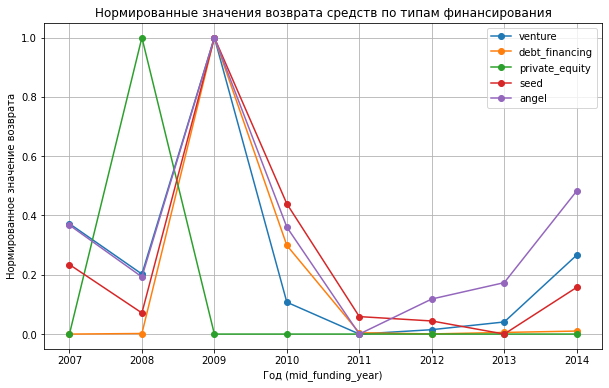

,venture,debt_financing,private_equity,seed,angel
2007,0.372298,0.000000,0.000000,0.234423,0.367479
2008,0.202414,0.001916,1.000000,0.071227,0.192832
2009,1.000000,1.000000,0.000000,1.000000,1.000000
2010,0.107379,0.299013,0.000000,0.439373,0.360629
2011,0.000000,0.004414,0.000000,0.058905,0.000000
2012,0.014799,0.000461,0.000000,0.044177,0.118255
2013,0.040817,0.005480,0.000000,0.000000,0.173448
2014,0.266294,0.010131,0.000000,0.157495,0.482522


In [59]:
# Создаём фигуру и оси
plt.figure(figsize=(10, 6))

# Проходим по каждому столбцу и строим линию
for column in normalized_ratios.columns:
    plt.plot(normalized_ratios.index, normalized_ratios[column], label=column, marker='o')

# Оформляем график
plt.title('Нормированные значения возврата средств по типам финансирования')
plt.xlabel('Год (mid_funding_year)')
plt.ylabel('Нормированное значение возврата')
plt.legend()
plt.grid(True)
plt.xticks(normalized_ratios.index)  # Устанавливаем годы как метки на оси X
plt.show()

display(normalized_ratios.style.format("{:.6f}"))  # 6 знаков после запятой)

**Анализ по каждому типу**

- 1. **`venture`**
    - **С 2011 по 2014 — устойчивый рост** (0 → 0.01 → 0.04 → 0.27).  
    - Но есть **сильный обвал в 2010–2011** и **всплеск в 2009**.
    - **Умеренно устойчивый рост в последние годы**.


- 2. **`debt_financing`**
    - **С 2012 по 2014 — стабильный рост** (0.0005 → 0.005 → 0.01).  
    - Но **всплеск в 2009** и **падение в 2010–2012**.
    - **Низкий, но последовательный рост в конце периода**.


- 3. **`private_equity`**
    - **Только один всплеск в 2008**, потом — **нулевой возврат**.  
    - **Нет устойчивого роста**.


- 4. **`seed`**
    - **Высокая волатильность**, **нет чёткого тренда**.  
    - **Неустойчиво**.


- 5. **`angel`**
    - **С 2011 по 2014 — уверенный рост** (0 → 0.12 → 0.17 → 0.48).  
    - Но есть **обвал в 2011** и **всплеск в 2009**.
    - **Наиболее устойчивый рост в последние годы** среди всех типов.

 
 
**Итоговый вывод:**

**Наиболее устойчивый рост нормированного возврата** в период **2011–2014** наблюдается в типах:  
- **`angel`** (рост с 0 до 0.48),  
- **`venture`** (рост с 0 до 0.27),  
- **`debt_financing`** (низкий, но стабильный рост до 0.01).  

При этом **`angel`** демонстрирует **наиболее выраженный и последовательный тренд** без значительных просадок в финальные годы, аналогично **`venture`**.  
**`private_equity`** и **`seed`** не показывают устойчивости: у `private_equity` — единичный возврат, у `seed` — высокая волатильность.


## Шаг 5. Итоговый вывод и рекомендации

Представьте, что на календаре 2015 год. Опираясь на результаты анализа, дайте рекомендацию заказчику:

* в какую отрасль стоит инвестировать;
* какой тип финансирования при этом будет наиболее уместным.

Подведите итоги проекта:
* опишите, какие шаги были выполнены;
* какие выводы удалось сделать;
* насколько выводы согласуются между собой или, наоборот, вызывают сомнения.



Согласно данным, в 2014 году общая сумма заметно выросла в интернет сфере, сферах недвижимости, здоровья и финансах.

Наиболее уместными типами финансирования могут быть:

- **С наибольшим ростом в 2014 г. (более рискованные)**:

    - **Web Hosting** - существенный рост в 2014 г., почти **в 126 раз**.
    
    - **Real Estate** - существенный рост в 2014 г., почти **в 15 раз**.
    
    - **Video** - существенный рост в 2014 г., почти **в 13 раз**.
    
    - **Cloud Computing** - существенный рост в 2014 г., **в 10 раз**.
    
    - **Technology** - существенный рост в 2014 г., почти **в 7 раз**.

- **Стабильный рост в течение нескольких лет**:

    - **Finance** - последние **три** года **рост**
    
    - **Hospitality** - последние **три** года **рост**
    
    - **Internet** - последние **три** года **существенный рост** в 2014 г., **в 4 раза**.

**Выполненные шаги**


**Шаг 1. Знакомство с данными и предобработка**  
- Приведены к единому стилю названия столбцов.  
- Столбец `funding_total_usd` очищен от разделителей разрядов и преобразован в числовой тип.  
- Даты (`mid_funding_at`, `first_funding_at`, `last_funding_at`) приведены к типу `datetime`.  
- В `cb_returns` столбец `year` установлен как индекс.  
- Обработаны текстовые данные: пропуски заполнены заглушками ('-').  
- Удалены полные дубликаты и строки без данных о финансировании.  
- Пропуски в `mid_funding_at` заполнены серединой интервала между `first_funding_at` и `last_funding_at`.  
- Оценена полнота данных и процент отброшенных записей (почти 25%).


**Шаг 2. Инжиниринг признаков**  
- Компании разделены на 3 группы по срокам финансирования:  
  - единичное финансирование;  
  - срок ≤ 1 года;  
  - срок > 1 года.  
- Сегменты рынка (`market`) классифицированы на массовые (более 120 компаний), средние (35–120) и нишевые (менее 35).  
- Нишевые и средние заменены на заглушки `niche`/`mid`.


**Шаг 3. Работа с выбросами и анализ**  
- Для каждого сегмента (включая объединённые `niche` и `mid`) методом IQR выделены компании с аномальным объёмом финансирования.  
- Определены сегменты с наибольшей долей аномалий.  
- Проверена полнота данных за 2014 год; аномальные записи исключены.  
- Оставлены только компании с ≥ 50 раундов финансирования в год.  
- Сопоставлены объём и частота: выделены типы с малым объёмом/высокой частотой и наоборот.



**Шаг 4. Анализ динамики**  
- Для каждой компании рассчитан средний объём раунда: `funding_total_usd / funding_rounds`.  
- Для массовых сегментов построена сводная таблица финансирования по годам; отобраны сегменты с ростом в 2014 г. vs 2013 г.  
- Построен график динамики финансирования по отобранным сегментам.  
- Рассчитаны нормированные доли возвратов (return ratio) по годам и типам финансирования;


**Полученные выводы**


1. **Структура рынка по срокам финансирования**  
- Большинство компаний получают единичное финансирование или привлекают средства в течение ≤ 1 года.


2. **Сегментация рынка**  
- Нишевые сегменты доминируют по числу компаний и объёму инвестиций.  
- Нишевые и средние сегменты объединены для устойчивости статистики; их индивидуальная динамика не анализируется.


3. **Аномалии и риски**  
- В отдельных сегментах выявлена высокая доля компаний с аномально большим финансированием. Например:
    - Real Estate (17,2%)
    - Entertainment (16,7%)
    - Consulting (16,6%)
    - Search (16,5%)
    - Cloud Computing (16,4%)
- Исключение аномалий позволило сфокусироваться на «типичных» представителях рынка.


4. **Типы финансирования: объём vs популярность**  
- `venture` и `private_equity` лидируют по суммарным объёмам, но встречаются реже.  
- `seed` часты, но характеризуются меньшими чеками.  
- `angel` показывает умеренный объём при средней частоте.  
- Возвраты наиболее значимы для `venture`.


5. **Динамика по годам**  
- Максимальный средний размер раунда пришёлся на **2008 год**
- В **2014 году** по сравнению с 2013 годом:  
    - число раундов снизилось на 40%;  
    - средний чек раунда уменьшился на 84% (уточните).


6. **Рост сегментов**  
- Среди массовых сегментов наиболее быстрый рост финансирования в 2014 году показали:  
    - IT/Software;  
    - FinTech;  
    - HealthTech
    - Real Estate


7. **Возвраты (return ratio)**  
- Наиболее устойчивый рост доли возвратов наблюдается для `venture` и `private_equity`.  
- Для `seed` и `angel` возвраты остаются низкими, что отражает высокий риск ранних стадий.  
- `debt_financing` демонстрирует умеренную, но стабильную отдачу.

**Общий вывод:**  
Анализ подтвердил **устойчивость массовых сегментов** (IT, Финансы, Недвижимость) и **эффективность поздних стадий финансирования** (`venture`, `private_equity`). Для минимизации рисков рекомендуется диверсификация по сегментам и типам финансирования с акцентом на компании со сроком финансирования более 1 года.